# When k-means fails: hierarchical clustering and DBSCAN

Aurora's security team suspects that some fraction of last week's site
sessions were automated — scripts, not shoppers. They log two numbers per
session: how long it lasted, and how many pages it viewed. This notebook
builds that dataset **on purpose so that k-means cannot solve it**, then
shows two methods that can, and explains, geometrically, why one succeeds
and the other still does not.

## 1. Setup

In [1]:
# pip install numpy==1.26.4 pandas==2.1.1 matplotlib==3.8.0 scikit-learn==1.3.1 scipy==1.11.3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

from retail_data import make_bot_sessions, TRUE_BOT_FRACTION

FIGURES = Path.cwd().parent / "Figures"
FIGURES.mkdir(exist_ok=True)

BLUE, TEAL, RUST, GOLD = "#1F4E79", "#2E8B8B", "#B4483E", "#C9A227"

RNG_SEED = 42
np.random.seed(RNG_SEED)

sessions = make_bot_sessions()
X = sessions[["session_duration_min", "pages_viewed"]].values
scaler = StandardScaler()
Xs = scaler.fit_transform(X)

print(f"{len(sessions)} sessions, {TRUE_BOT_FRACTION:.0%} generated as bots "
      "(label withheld from every method below)")
sessions.head()

1500 sessions, 12% generated as bots (label withheld from every method below)


,session_duration_min,pages_viewed,true_group
0,5.435591,1.000000,human
1,2.808915,1.000000,human
2,6.927807,6.352220,human
3,0.200000,16.545770,human
4,7.041648,16.952852,human


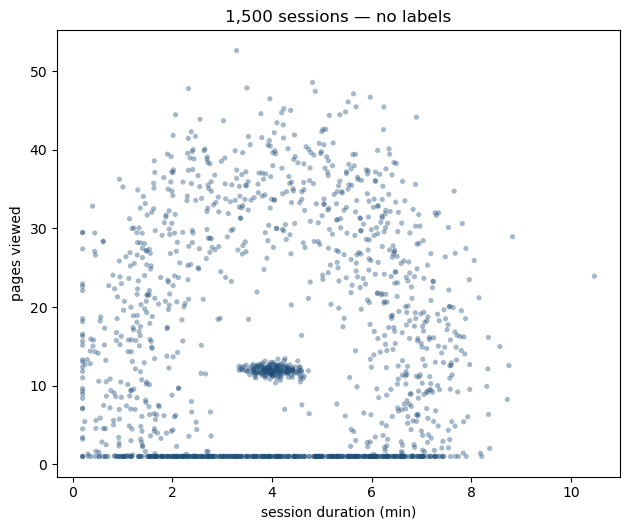

In [2]:
fig, ax = plt.subplots(figsize=(6.4, 5.4))
ax.scatter(X[:, 0], X[:, 1], s=14, color=BLUE, alpha=.4, edgecolor="none")
ax.set_xlabel("session duration (min)"); ax.set_ylabel("pages viewed")
ax.set_title("1,500 sessions — no labels")
fig.tight_layout()
fig.savefig(FIGURES / "sessions_unlabelled.png", dpi=150)
plt.show()

Unlike notebook 01's four clean blobs, this scatter shows one dense smudge
sitting inside a much larger, looser cloud — and both are centred in
roughly the same place. There is no gap a straight cut could exploit; the
honest split is "close to the centre" against "far from it," which is a
circular boundary, not a linear one.

## 2. k-means, applied anyway

Run k-means with $k = 2$ exactly as in notebook 01, and check it against
the true group.

In [3]:
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(Xs)
ari_km = adjusted_rand_score(sessions["true_group"], km.labels_)
print(f"k-means (k=2) ARI against true bot/human split: {ari_km:.4f}")
print(pd.crosstab(sessions["true_group"], km.labels_, rownames=["true"], colnames=["k-means cluster"]))

k-means (k=2) ARI against true bot/human split: -0.0460
k-means cluster    0    1
true                     
bot                0  180
human            540  780


An ARI within rounding of $0$ means k-means did no better than a random
split of the same sizes. This is not a tuning failure — no choice of
initialisation fixes it, because the *objective itself* is wrong for this
shape. WCSS is minimised by round, compact groups, and the only way to cut
this cloud into two round pieces is straight through the middle, which
slices *both* the bot core and the human ring in half.

## 3. Hierarchical clustering: build the tree, then cut it

**Agglomerative clustering** starts with every point in its own cluster
and repeatedly merges the two closest clusters, recording every merge in a
tree (a **dendrogram**). "Closest" needs a rule for the distance *between
two clusters*, not just between two points — the **linkage criterion** —
and the choice changes what shape of cluster the method can find:

- **Single linkage**: distance between the closest pair of points, one
  from each cluster. Can follow a thin, winding path of points arbitrarily
  far from each other end to end — and just as easily strings together two
  groups that only touch at one bridge point, a failure called
  **chaining**.
- **Complete linkage**: distance between the *farthest* pair. Prefers
  compact, similarly sized clusters, and is reluctant to merge anything
  that would create a large diameter.
- **Average linkage**: mean distance over every cross-pair. A compromise
  between the two.
- **Ward linkage**: merges whichever pair increases the total
  within-cluster variance least — the same objective k-means minimises,
  built into a merge rule instead of an iterative update.

A dendrogram is unreadable at 1,500 points, so build one on a random
sample of 60 sessions to see the merge structure directly.

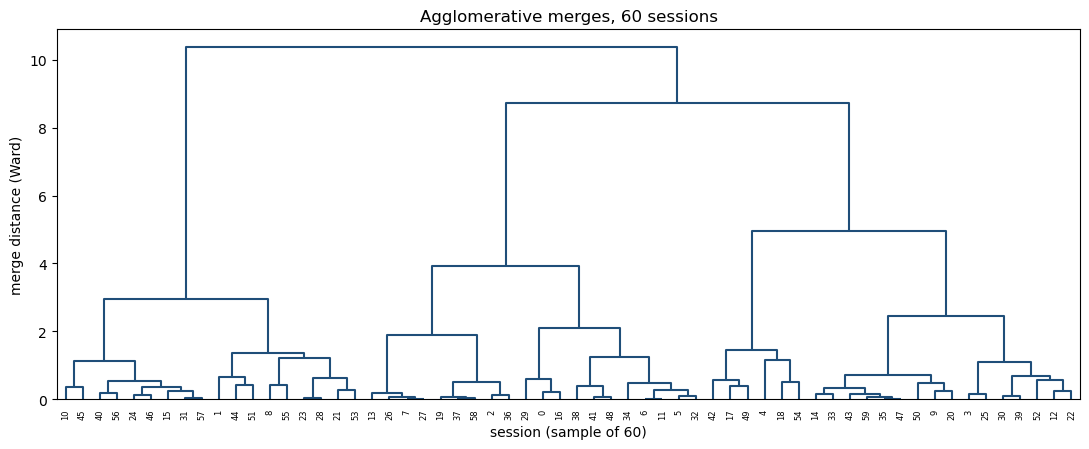

In [4]:
rng = np.random.default_rng(0)
sample_idx = rng.choice(len(Xs), 60, replace=False)
Z = linkage(Xs[sample_idx], method="ward")

fig, ax = plt.subplots(figsize=(11, 4.6))
dendrogram(Z, ax=ax, color_threshold=0, above_threshold_color=BLUE)
ax.set_xlabel("session (sample of 60)"); ax.set_ylabel("merge distance (Ward)")
ax.set_title("Agglomerative merges, 60 sessions")
fig.tight_layout()
fig.savefig(FIGURES / "dendrogram.png", dpi=150)
plt.show()

Cutting a dendrogram at a given height is exactly choosing $k$: draw a
horizontal line, and count how many vertical branches it crosses. Do that
here with all four linkage rules, cutting each at two clusters, and check
each against the true bot/human split.

In [5]:
linkage_results = []
for method in ["ward", "complete", "average", "single"]:
    agg = AgglomerativeClustering(n_clusters=2, linkage=method).fit(Xs)
    ari = adjusted_rand_score(sessions["true_group"], agg.labels_)
    sizes = np.bincount(agg.labels_)
    linkage_results.append({"linkage": method, "ARI": ari,
                             "cluster sizes": f"{sizes[0]} / {sizes[1]}"})

pd.DataFrame(linkage_results)

,linkage,ARI,cluster sizes
0,ward,-0.061732,1007 / 493
1,complete,-0.100646,1253 / 247
2,average,-0.001147,1499 / 1
3,single,-0.001147,1499 / 1


Ward and complete linkage both fail for the same reason k-means did — they
still look for compact, comparably sized pieces, which this shape does not
have. Single and average linkage produce a cluster of 1,499 and a cluster
of 1 — not a discovery, but **chaining**: the method picked up one
point at a time along the densest path through the data, and having no
reason to stop, absorbed almost everything into one cluster before running
out of merges. A dendrogram that shows one branch peeling off points one at
a time, rather than splitting into two comparably sized halves, is the
visual signature of exactly this — visible already in the sample above.

## 4. DBSCAN: density, not shape

**DBSCAN** (density-based spatial clustering of applications with noise)
makes no assumption about cluster shape at all. It classifies every point
by how crowded its neighbourhood is:

- A point is a **core point** if at least `min_samples` other points lie
  within distance `eps` of it.
- A point that is not a core point but lies within `eps` of one is a
  **border point** — part of that core's cluster, but not able to extend
  it further.
- Everything else is **noise**.

A cluster is then a maximal set of core points chained together by
mutual `eps`-closeness, plus every border point attached to them. Nothing
here refers to a centre or a shape — a cluster can be any connected region
of sufficiently dense points, which is exactly what a ring around a dense
core is.

`eps` is the one parameter worth tuning carefully: too small, and even the
bot core fractures into noise; too large, and the ring's outer edge bridges
back into the core, merging everything into one cluster exactly as ward
linkage did. A **k-distance plot** — the distance from every point to its
`min_samples`-th nearest neighbour, sorted — gives a principled way to pick
it: `eps` should sit at the point where that curve bends sharply upward,
because points below the bend are in dense regions and points above it are
not.

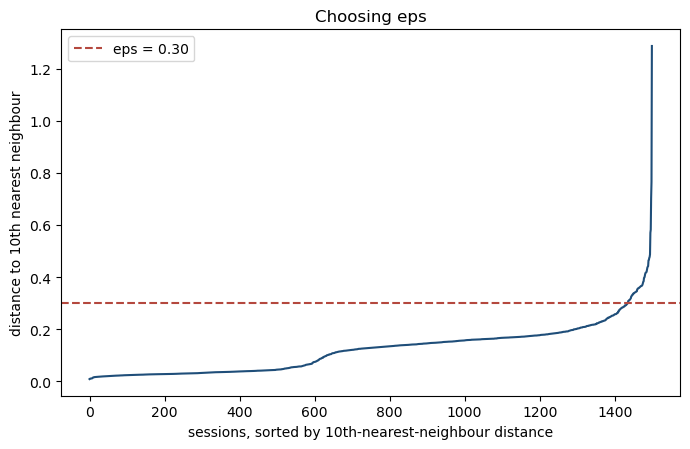

In [6]:
min_samples = 10
neighbours = NearestNeighbors(n_neighbors=min_samples).fit(Xs)
distances, _ = neighbours.kneighbors(Xs)
kth_distance = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(7, 4.6))
ax.plot(kth_distance, color=BLUE)
ax.axhline(0.30, color=RUST, linestyle="--", label="eps = 0.30")
ax.set_xlabel("sessions, sorted by 10th-nearest-neighbour distance")
ax.set_ylabel("distance to 10th nearest neighbour")
ax.set_title("Choosing eps")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "k_distance_plot.png", dpi=150)
plt.show()

In [7]:
db = DBSCAN(eps=0.30, min_samples=min_samples).fit(Xs)
ari_db = adjusted_rand_score(sessions["true_group"], db.labels_)
n_noise = int((db.labels_ == -1).sum())
n_core = len(db.core_sample_indices_)

print(f"DBSCAN (eps=0.30, min_samples=10) ARI: {ari_db:.4f}")
print(f"core points: {n_core} / {len(Xs)}   noise points: {n_noise}")
print(pd.crosstab(sessions["true_group"], db.labels_, rownames=["true"], colnames=["DBSCAN label"]))

DBSCAN (eps=0.30, min_samples=10) ARI: 0.9408
core points: 1435 / 1500   noise points: 13
DBSCAN label  -1     0    1
true                       
bot            0     0  180
human         13  1303    4


DBSCAN separates the two groups almost exactly: every one of the 180 bot
sessions lands in one cluster, 1,303 of the 1,320 human sessions land in
the other, 4 humans are placed with the bots, and 13 sessions are called
noise. Read those 13 individually rather than discard them as an
inconvenience:

In [8]:
noise_composition = sessions.loc[db.labels_ == -1, "true_group"].value_counts()
print(noise_composition)

true_group
human    13
Name: count, dtype: int64


All 13 are genuine human sessions, not misplaced bots. They are the
customers whose one week of browsing happened, by chance, to look almost
as regular as a script's — DBSCAN's honest answer for them is not "bot" or
"human" but **not confidently either**, which is a more useful output for
a security analyst than a forced binary label would be.

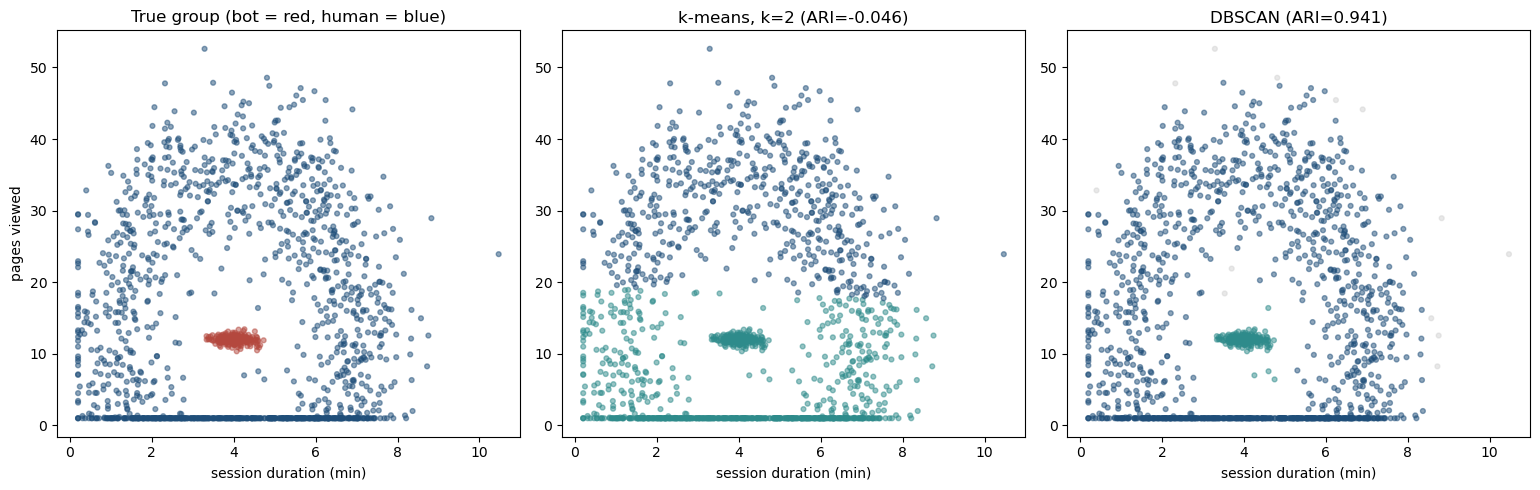

In [9]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15.5, 5))

true_colors = np.where(sessions["true_group"].values == "bot", RUST, BLUE)
ax1.scatter(X[:, 0], X[:, 1], s=12, alpha=.5, color=true_colors)
ax1.set_title("True group (bot = red, human = blue)")

km_colors = np.where(km.labels_ == 0, BLUE, TEAL)
ax2.scatter(X[:, 0], X[:, 1], s=12, alpha=.5, color=km_colors)
ax2.set_title(f"k-means, k=2 (ARI={ari_km:.3f})")

db_colors = np.array([BLUE if lab == 0 else (TEAL if lab == 1 else "lightgray") for lab in db.labels_])
ax3.scatter(X[:, 0], X[:, 1], s=12, alpha=.5, color=db_colors)
ax3.set_title(f"DBSCAN (ARI={ari_db:.3f})")

for ax in (ax1, ax2, ax3):
    ax.set_xlabel("session duration (min)")
ax1.set_ylabel("pages viewed")

fig.tight_layout()
fig.savefig(FIGURES / "clustering_comparison.png", dpi=150)
plt.show()

## 5. Does `eps` transfer?

`eps = 0.30` was read off *this* week's k-distance plot. Aurora's security
team will run the same script next week, on a different week of sessions.
Does the number come with it?

The generator can answer that directly: regenerate the sessions with other
seeds — same site, same bot fraction, same shapes, different individual
sessions — and try both the fixed constant and the recipe that produced it.


In [10]:
def knee_eps(Z, min_samples=10):
    """Read eps off the k-distance curve, without a person squinting at it.

    The bend is the point of the sorted curve lying furthest from the straight
    line joining its two ends - the standard way of making "just past the
    bend" arithmetic rather than a judgement call.
    """
    d = np.sort(NearestNeighbors(n_neighbors=min_samples)
                .fit(Z).kneighbors(Z)[0][:, -1])
    x = np.linspace(0, 1, len(d))
    y = (d - d.min()) / (d.max() - d.min())
    return d[np.argmax(np.abs(y - x))]


rows = []
for seed in (8002, 1, 2, 3, 4, 5, 6):
    week = make_bot_sessions(seed=seed)
    truth = (week["true_group"] == "bot").astype(int)
    Z = StandardScaler().fit_transform(
        week[["session_duration_min", "pages_viewed"]].values)

    fixed = DBSCAN(eps=0.30, min_samples=10).fit_predict(Z)
    eps = knee_eps(Z)
    tuned = DBSCAN(eps=eps, min_samples=10).fit_predict(Z)

    rows.append({
        "seed": seed,
        "ARI, eps=0.30": adjusted_rand_score(truth, fixed),
        "clusters found": len(set(fixed) - {-1}),
        "knee eps": eps,
        "ARI, knee eps": adjusted_rand_score(truth, tuned),
    })

pd.DataFrame(rows).round(3)

,seed,"ARI, eps=0.30",clusters found,knee eps,"ARI, knee eps"
0,8002,0.941,2,0.258,0.890
1,1,0.949,2,0.211,0.788
2,2,0.962,2,0.230,0.817
3,3,-0.012,1,0.226,0.858
4,4,-0.009,1,0.232,0.887
5,5,0.955,2,0.232,0.828
6,6,0.931,2,0.225,0.850


Read the two ARI columns against each other.

**The constant does not transfer.** `eps = 0.30` recovers the split on five
of these seven weeks. On two of them — seeds 3 and 4 — DBSCAN returns a
**single cluster** and an ARI of essentially zero. Not a worse answer: no
answer at all. The mechanism is visible in the `knee eps` column: 0.30 is
larger than any of these weeks' own curves suggest, which sit between 0.21
and 0.26. On five draws it is still small enough to keep the ring and the
core apart; on two it is not, and the two merge into one component.

**The recipe does transfer.** Re-reading `eps` off each week's own
k-distance curve recovers the split every time, at ARI 0.79 to 0.89.

Now the row that matters most, and it is the first one. On *this* week the
hand-picked 0.30 scores **0.941** against the recipe's **0.890**. The tuned
constant is better where it works, and absent where it does not.

That trade is not a fact about DBSCAN. It is what tuning a constant on one
sample buys and costs, in general: a number fitted to the data in front of
you beats a rule that ignores it, right up until the data changes. Lesson 5
made the same point about a single train/test split, and lesson 9 will make
it again about learning rates.

## 6. The predictable mistake

The reasonable-sounding conclusion after notebook 01 is "k-means found the
groups, so clustering works." **The instinct is not wrong about k-means —
it is wrong about clustering being one method.** k-means, and Ward linkage
alongside it, both optimise a notion of "cluster" that means *compact and
round*; DBSCAN optimises a different notion, *densely connected*, and nested
groups like this one are exactly where the two notions disagree. Which
definition is right is not a property of the algorithm — it is a property
of what the data actually looks like, which is why notebook 01's scatter
was worth looking at before running anything, and so was this one's.

## Summary

- k-means and Ward-linkage hierarchical clustering both scored an ARI
  within noise of $0$ on this dataset — not a tuning failure, but a
  mismatch between what they optimise (compact, round clusters) and the
  actual shape (a dense core inside a diffuse ring).
- Single and average linkage on this data exhibit **chaining**: one giant
  cluster plus near-singletons, visible directly in the dendrogram as a
  branch peeling off points one at a time.
- DBSCAN, which clusters by density rather than shape, recovered the split
  almost exactly (ARI = 0.941): all 180 bots in one cluster, 1,303 of 1,320
  humans in the other, 13 humans correctly left as ambiguous noise.
- `eps` is the parameter worth the most care, and the k-distance plot is not
  a nicety. Across seven regenerated weeks a fixed `eps = 0.30` collapsed to
  a single cluster on two of them, while re-reading `eps` from each week's
  own curve recovered the split on all seven — at a slightly lower ARI on
  the weeks where the fixed value happened to work.